In [22]:
import pandas as pd 
import matplotlib.pyplot as plt


df = pd.read_csv("C:/Users/orban/Downloads/electricity_consumption_and_production.csv", parse_dates=True, index_col='DateTime')
series = df['Consumption']

series = series[~series.index.duplicated(keep='first')]
daily_series = series.resample('D').mean().interpolate(method='linear')

df.head()


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


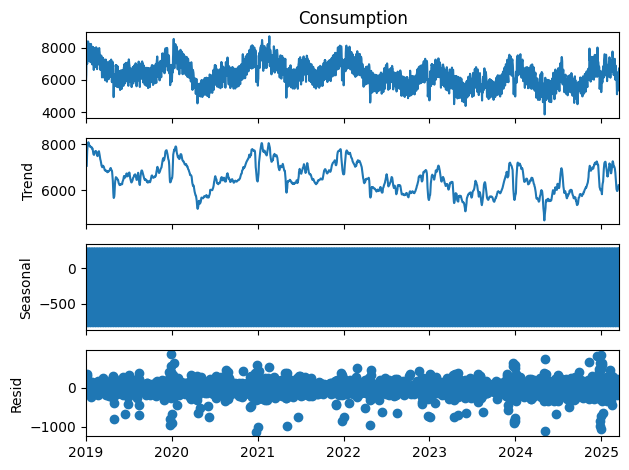

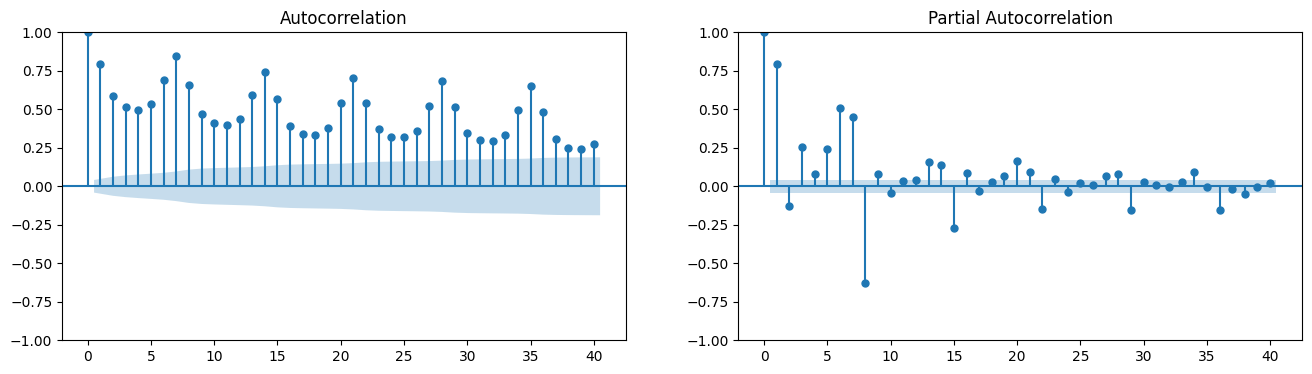

ADF Statistic: -3.3878121500084344
p-value: 0.011381438151791644


In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

decomposition = seasonal_decompose(daily_series.dropna(), period = 7)
decomposition.plot()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(daily_series.dropna(), lags=40, ax=ax[0])
plot_pacf(daily_series.dropna(), lags=40, ax=ax[1])
plt.show()

adf_result = adfuller(daily_series.dropna())
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

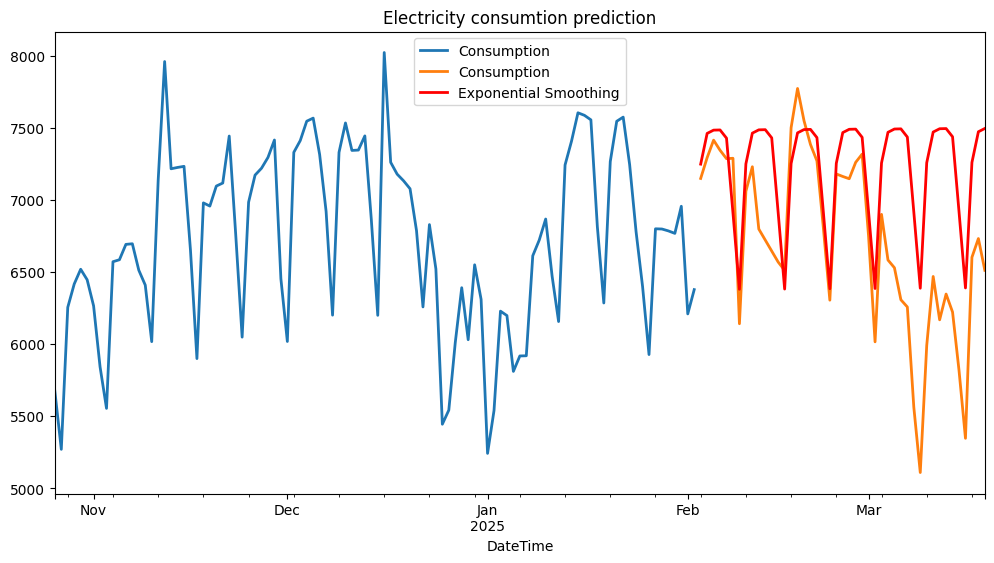

MAPE Error: 8.73%


In [21]:
from darts import TimeSeries
from darts.models import ExponentialSmoothing
from darts.metrics import mape

ts = TimeSeries.from_series(daily_series)

train, val = ts[:-45], ts[-45:]

model_es = ExponentialSmoothing()

model_es.fit(train)

pred_15 = model_es.predict(n=15)
pred_30 = model_es.predict(n=30)
pred_45 = model_es.predict(n=45)

plt.figure(figsize=(12, 6))
train[-100:].plot()
val.plot()
pred_45.plot(label="Exponential Smoothing", color='red', linewidth=2)
plt.title("Electricity consumtion prediction")
plt.legend()
plt.show()

error_mape = mape(val, pred_45)
print(f"MAPE Error: {error_mape:.2f}%")